<a href="https://colab.research.google.com/github/MelCrespo/ProcesosEstocasticos/blob/main/02_Introduccion_a_Procesos_Estocasticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Estacionariedad Estricta
Un proceso es **estrictamente estacionario** si sus propiedades estadísticas (su distribución de probabilidad conjunta) son completamente invariantes ante traslaciones en el tiempo.

En la práctica, esto significa que el comportamiento visual, los momentos (media, varianza) y la forma de la distribución son idénticos en cualquier ventana de tiempo que elijamos. El ejemplo clásico por excelencia es el **Ruido Blanco Gaussiano**.

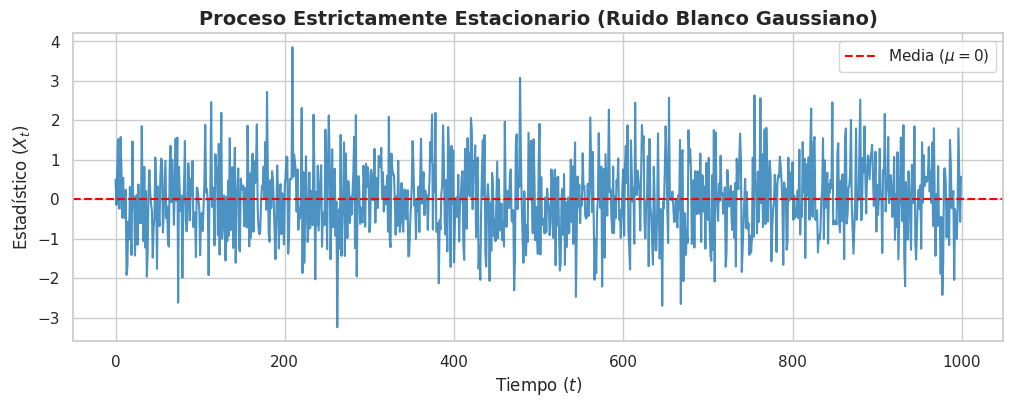

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
sns.set_theme(style="whitegrid")
N = 1000 # Numero de muestras de la serie

# Generación de datos
ruido_blanco = np.random.normal(loc=0, scale=1, size=N)
df_estricta = pd.DataFrame({'Tiempo': np.arange(N), 'Valor': ruido_blanco})

# Graficación
plt.figure(figsize=(12, 4))
sns.lineplot(data=df_estricta, x='Tiempo', y='Valor', color='tab:blue', alpha=0.8)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label=r'Media ($\mu=0$)')

plt.title('Proceso Estrictamente Estacionario (Ruido Blanco Gaussiano)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo ($t$)')
plt.ylabel('Estadístico ($X_t$)')
plt.legend(loc='upper right')
plt.show()

## 2. Estacionariedad en Sentido Amplio / Débil (WSS)
La **Estacionariedad en Sentido Amplio** es menos restrictiva. Solo exige dos condiciones:
1. La **media** es constante en el tiempo ($E[X_t] = \mu$).
2. La **autocovarianza** depende únicamente del desfase ($h$) entre dos puntos, no del tiempo absoluto.

Para demostrar que un proceso puede ser WSS pero **NO** estricto, simularemos una serie que cambia de distribución (pasa de Gaussiana a Uniforme) cada 200 pasos. Ambas distribuciones se configuran para tener exactamente la misma media ($\mu=0$) y varianza ($\sigma^2=1$).

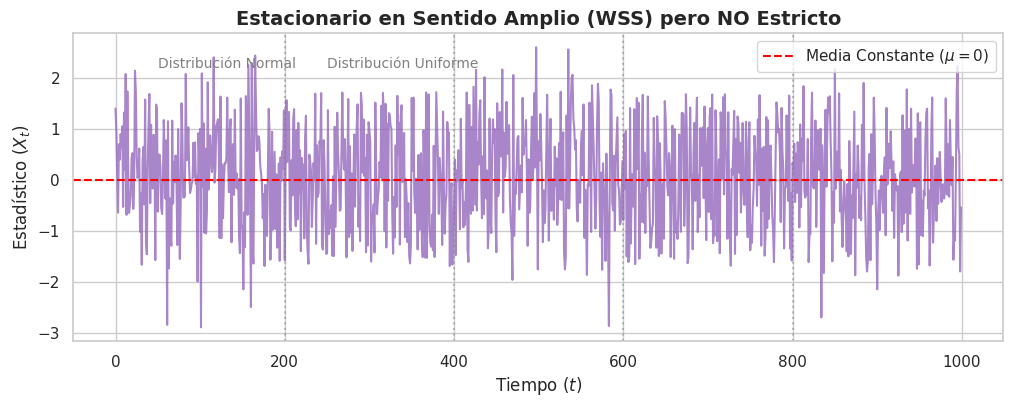

In [2]:
# Generación de datos WSS pero No Estricta
wss_no_estricta = np.zeros(N)
for i in range(0, N, 200):
    if (i // 200) % 2 == 0:
        wss_no_estricta[i:i+200] = np.random.normal(0, 1, 200) # Distribución Normal
    else:
        # Varianza de Uniforme(-sqrt(3), sqrt(3)) es 1
        wss_no_estricta[i:i+200] = np.random.uniform(-np.sqrt(3), np.sqrt(3), 200) # Distribución Uniforme

df_wss = pd.DataFrame({'Tiempo': np.arange(N), 'Valor': wss_no_estricta})

# Graficación
plt.figure(figsize=(12, 4))
sns.lineplot(data=df_wss, x='Tiempo', y='Valor', color='tab:purple', alpha=0.8)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label=r'Media Constante ($\mu=0$)')

# Marcadores para visualizar los cambios de estructura/distribución
for corte in range(200, N, 200):
    plt.axvline(corte, color='gray', linestyle=':', alpha=0.5)

plt.title('Estacionario en Sentido Amplio (WSS) pero NO Estricto', fontsize=14, fontweight='bold')
plt.text(50, 2.2, 'Distribución Normal', fontsize=10, color='gray')
plt.text(250, 2.2, 'Distribución Uniforme', fontsize=10, color='gray')
plt.xlabel('Tiempo ($t$)')
plt.ylabel('Estadístico ($X_t$)')
plt.legend(loc='upper right')
plt.show()

## 3. Proceso No Estacionario (Tendencia)
Para contrastar los conceptos anteriores, este bloque muestra un proceso donde las propiedades estadísticas cambian explícitamente con el tiempo. Añadimos una **tendencia lineal**, lo que provoca que la media $E[X_t]$ dependa directamente de $t$, violando cualquier criterio de estacionariedad.

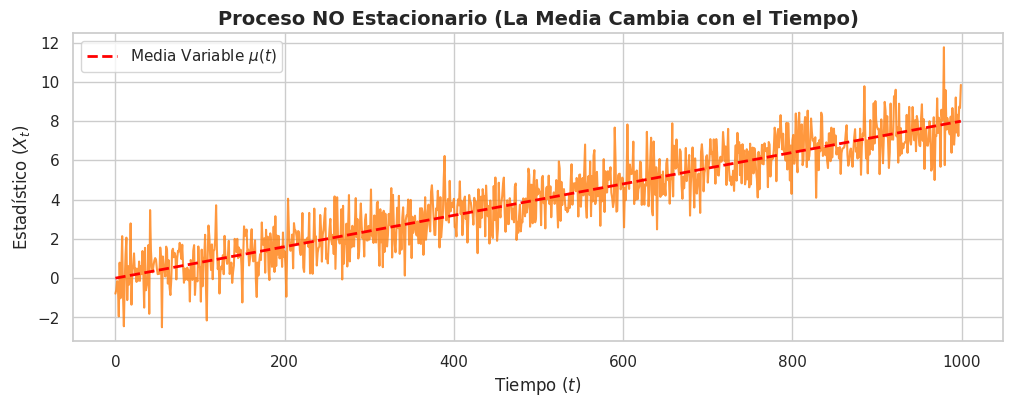

In [3]:
# Generación de datos con tendencia lineal
tendencia = 0.008 * np.arange(N)
no_estacionaria = tendencia + np.random.normal(0, 1, N)
df_no_estat = pd.DataFrame({'Tiempo': np.arange(N), 'Valor': no_estacionaria})

# Graficación
plt.figure(figsize=(12, 4))
sns.lineplot(data=df_no_estat, x='Tiempo', y='Valor', color='tab:orange', alpha=0.8)
plt.plot(np.arange(N), tendencia, color='red', linestyle='--', linewidth=2, label=r'Media Variable $\mu(t)$')

plt.title('Proceso NO Estacionario (La Media Cambia con el Tiempo)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo ($t$)')
plt.ylabel('Estadístico ($X_t$)')
plt.legend(loc='upper left')
plt.show()

## 4. Ergodicidad
Un proceso es **ergódico** si podemos deducir las propiedades de todo el sistema (el "ensamble" o conjunto de trayectorias posibles) observando únicamente **una sola realización** a lo largo del tiempo.

* **Ergódico:** El promedio temporal de una sola serie converge a la media teórica de todo el ensamble.
* **No Ergódico:** Cada serie individual converge a un valor propio y aislado. Una sola trayectoria no es capaz de representar la realidad global del proceso.

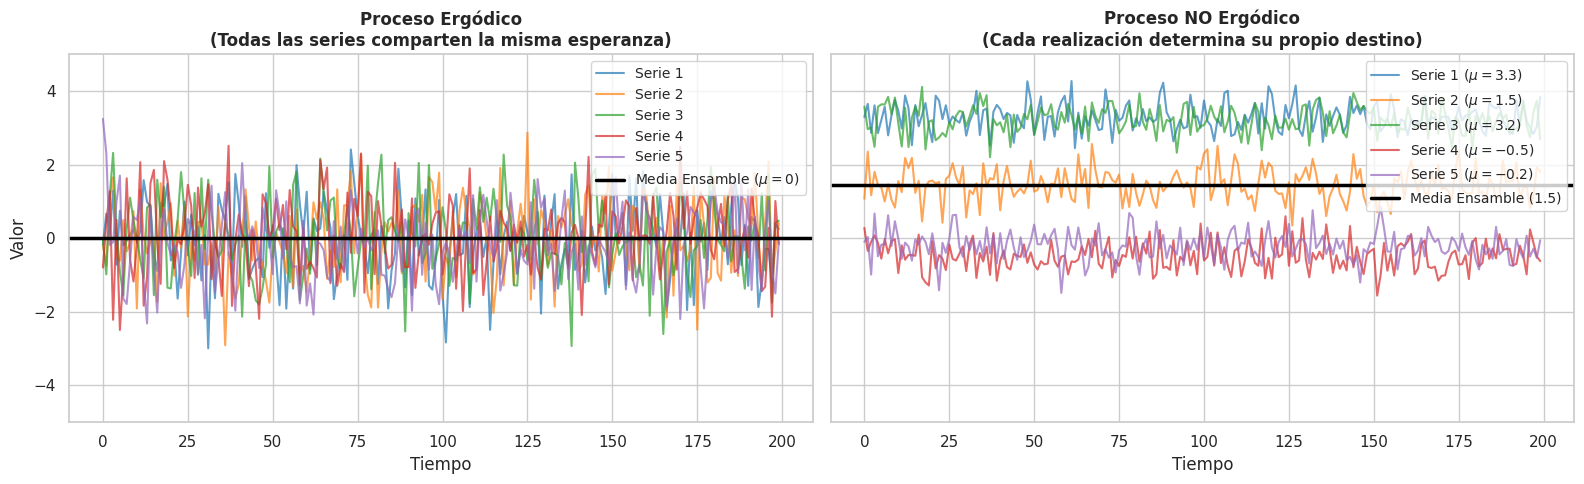

In [4]:
num_series = 5
pasos = 200
tiempo_eje = np.arange(pasos)

# --- CASO A: PROCESO ERGÓDICO ---
datos_erg = []
for i in range(num_series):
    datos_erg.append(pd.DataFrame({
        'Tiempo': tiempo_eje, 'Valor': np.random.normal(0, 1, pasos), 'Realización': f'Serie {i+1}'
    }))
df_erg = pd.concat(datos_erg)

# --- CASO B: PROCESO NO ERGÓDICO ---
medias_aleatorias = np.random.uniform(-3.5, 3.5, num_series)
datos_no_erg = []
for i in range(num_series):
    datos_no_erg.append(pd.DataFrame({
        'Tiempo': tiempo_eje, 'Valor': np.random.normal(medias_aleatorias[i], 0.4, pasos), 'Realización': f'Serie {i+1}' + r' ($\mu=' + f'{medias_aleatorias[i]:.1f}$)'
    }))
df_no_erg = pd.concat(datos_no_erg)

# Graficación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Gráfico Ergódico
sns.lineplot(data=df_erg, x='Tiempo', y='Valor', hue='Realización', alpha=0.7, ax=ax1, palette='tab10')
ax1.axhline(0, color='black', linestyle='-', linewidth=2.5, label=r'Media Ensamble ($\mu=0$)')
ax1.set_title('Proceso Ergódico\n(Todas las series comparten la misma esperanza)', fontsize=12, fontweight='bold')
ax1.set_ylim(-5, 5)
ax1.legend(loc='upper right', fontsize='small')

# Gráfico No Ergódico
sns.lineplot(data=df_no_erg, x='Tiempo', y='Valor', hue='Realización', alpha=0.7, ax=ax2, palette='tab10')
ax2.axhline(medias_aleatorias.mean(), color='black', linestyle='-', linewidth=2.5, label=f'Media Ensamble ({medias_aleatorias.mean():.1f})')
ax2.set_title('Proceso NO Ergódico\n(Cada realización determina su propio destino)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

## 5. Autocorrelación (ACF)
La **autocorrelación** mide el grado de asociación lineal entre los valores de una serie y sus propios valores pasados a un desfase o lag $h$.

Para visualizar cómo la autocorrelación detecta dependencias temporales y patrones cíclicos, simularemos el comportamiento de la temperatura con un ciclo estacional de **24 horas**.

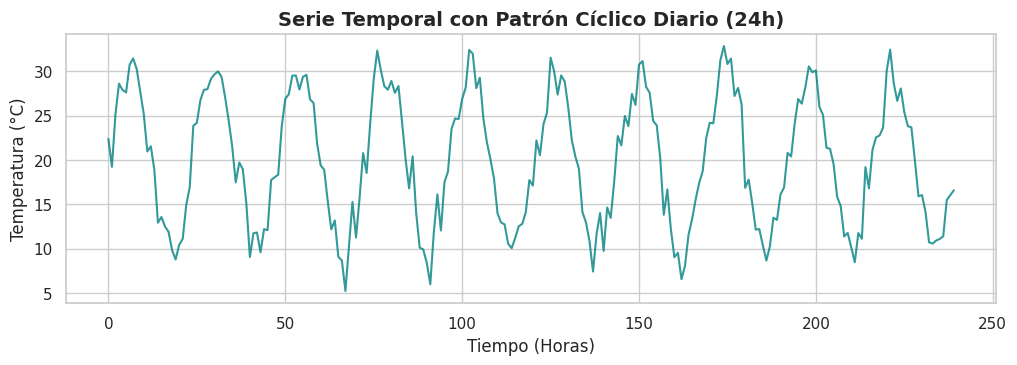

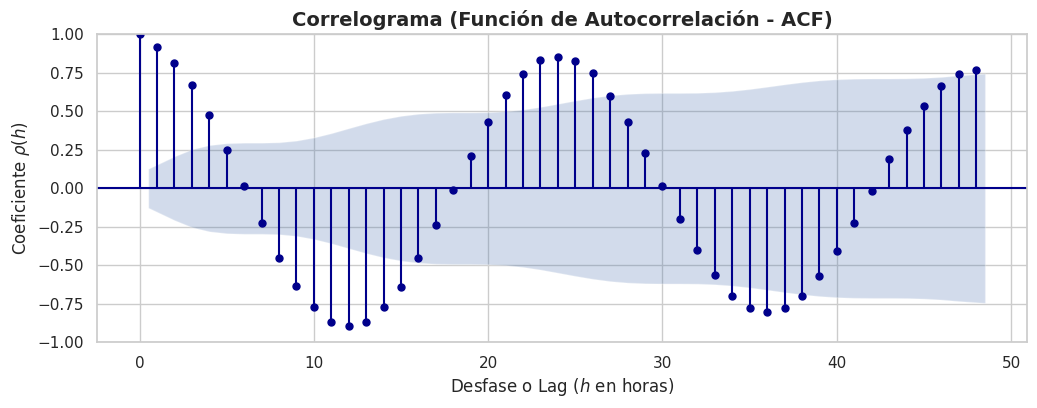

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

# Simulación de un proceso estacional (ej. Temperatura cada hora por 10 días)
horas = np.arange(240)
# Ciclo sinusoidal de 24 horas + ruido gaussiano
temperatura = 20 + 10 * np.sin(2 * np.pi * horas / 24) + np.random.normal(0, 1.8, 240)
df_clima = pd.DataFrame({'Hora': horas, 'Temperatura': temperatura})

# Graficación de la Serie Temporal
plt.figure(figsize=(12, 3.5))
sns.lineplot(data=df_clima, x='Hora', y='Temperatura', color='teal', alpha=0.8)
plt.title('Serie Temporal con Patrón Cíclico Diario (24h)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (Horas)')
plt.ylabel('Temperatura (°C)')
plt.show()

# Graficación del Correlograma (ACF)
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df_clima['Temperatura'], lags=48, ax=ax, color='darkblue', vlines_kwargs={"colors": 'darkblue'})
ax.set_title('Correlograma (Función de Autocorrelación - ACF)', fontsize=14, fontweight='bold')
ax.set_xlabel('Desfase o Lag ($h$ en horas)')
ax.set_ylabel(r'Coeficiente $\rho(h)$')
plt.show()

### ¿Cómo se interpreta el Correlograma (ACF)?

El correlograma, o **Función de Autocorrelación (ACF)**, es una herramienta gráfica fundamental para entender la dependencia temporal de una serie de tiempo. Muestra la correlación de una serie con sus propios valores pasados (rezagos o lags).

**Elementos clave para la interpretación:**

1.  **Eje Horizontal (Lags o Desfases):** Representa el número de unidades de tiempo que estamos "desfasando" la serie. Un lag de 1 significa la correlación entre el valor actual y el valor inmediatamente anterior; un lag de 2, entre el valor actual y el de dos unidades de tiempo atrás, y así sucesivamente.

2.  **Eje Vertical (Coeficiente de Correlación):** Indica el valor del coeficiente de correlación para cada lag, oscilando entre -1 y 1.
    *   **Cercano a 1:** Fuerte correlación positiva (los valores pasados y actuales tienden a moverse en la misma dirección).
    *   **Cercano a -1:** Fuerte correlación negativa (los valores pasados y actuales tienden a moverse en direcciones opuestas).
    *   **Cercano a 0:** Poca o ninguna correlación lineal.

3.  **Bandas de Confianza (Área Sombreada, generalmente azul):** Estas bandas indican los límites dentro de los cuales los coeficientes de autocorrelación son estadísticamente indistinguibles de cero (es decir, no son significativos). Cualquier barra (coeficiente) que se extienda fuera de estas bandas se considera estadísticamente significativa.

**Patrones comunes y su significado:**

*   **Caída Rápida a Cero (dentro de las bandas):** Típico de procesos de **Ruido Blanco** o series que ya son estacionarias. Sugiere que no hay dependencia lineal significativa entre los valores pasados y futuros.

*   **Disminución Lenta y Gradual:** Indica la presencia de **tendencia** en la serie. La serie es no estacionaria en media. Los valores altos de hoy predicen valores altos en el futuro, y viceversa, porque la serie está subiendo o bajando de forma sostenida.

*   **Patrón Sinusoidal o de Ondas (Oscilaciones):** Sugiere **estacionalidad** o ciclos periódicos en la serie. Los picos significativos aparecen a intervalos regulares (ej. cada 12 lags para datos mensuales o 24 para datos horarios, como en el ejemplo de temperatura).

*   **Un Pico Significativo en un Lag Específico, y luego Cero:** Puede indicar una dependencia de un modelo de Medias Móviles (MA) de ese orden.

*   **Decrecimiento Exponencial o Senoidal Amortiguado:** Puede sugerir un proceso Autorregresivo (AR).

**En resumen:**

El correlograma te ayuda a identificar:
*   Si la serie es **estacionaria** (media y varianza constantes a lo largo del tiempo).
*   La presencia de **tendencias**.
*   La existencia de **estacionalidad** o ciclos.
*   Posibles **modelos ARIMA** que podrían ajustarse a la serie.

## 6. Densidad Espectral

La **densidad espectral de potencia (PSD)** o **periodograma** es una herramienta fundamental en el análisis de series de tiempo para identificar las frecuencias dominantes o los componentes cíclicos de una señal. Nos muestra cómo se distribuye la potencia o la varianza de la señal en las distintas frecuencias.

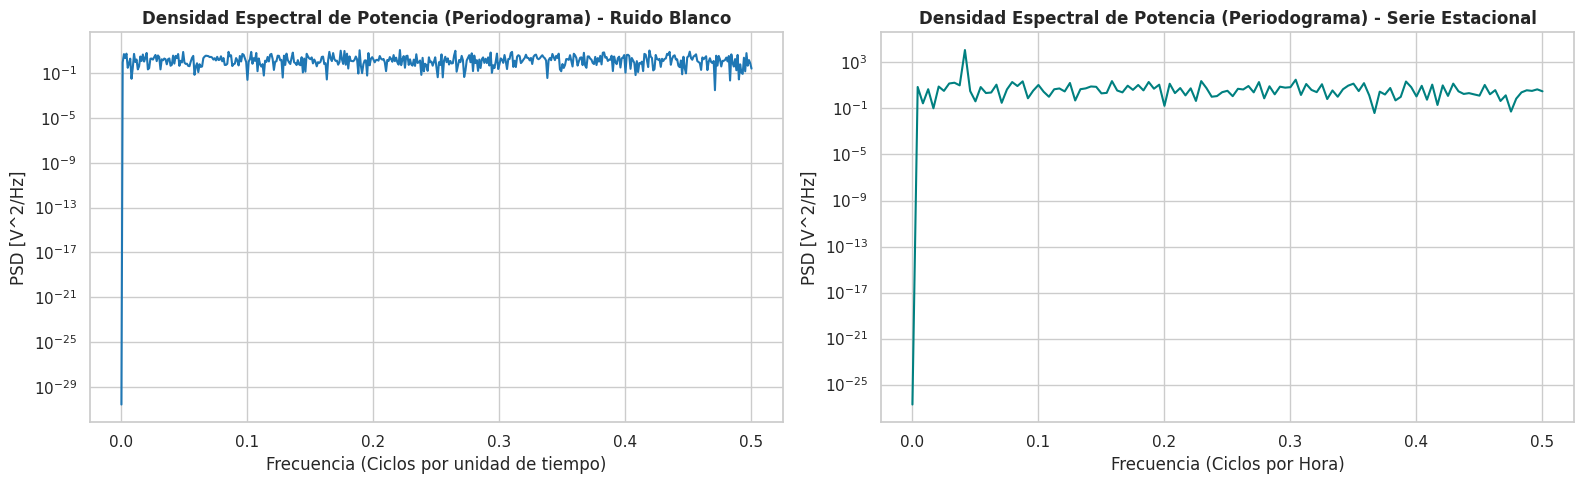

In [6]:
from scipy.signal import periodogram

# --- Análisis de Densidad Espectral para el Ruido Blanco Gaussiano ---
# Ya tenemos 'ruido_blanco' generado anteriormente

frecuencias_rw, psd_rw = periodogram(ruido_blanco, fs=1) # fs=1 as it's a discrete signal with unit sampling

# --- Análisis de Densidad Espectral para la Serie Temporal Estacional (Temperatura) ---
# Ya tenemos 'temperatura' generada anteriormente (muestra cada hora)

frecuencias_temp, psd_temp = periodogram(temperatura, fs=1) # fs=1 as it's a discrete signal (hours)

# --- Graficación de los Periodogramas ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Periodograma del Ruido Blanco
ax1.semilogy(frecuencias_rw, psd_rw, color='tab:blue')
ax1.set_title('Densidad Espectral de Potencia (Periodograma) - Ruido Blanco', fontsize=12, fontweight='bold')
ax1.set_xlabel('Frecuencia (Ciclos por unidad de tiempo)')
ax1.set_ylabel(r'PSD [V^2/Hz]')
ax1.grid(True)

# Periodograma de la Serie Estacional
ax2.semilogy(frecuencias_temp, psd_temp, color='teal')
ax2.set_title('Densidad Espectral de Potencia (Periodograma) - Serie Estacional', fontsize=12, fontweight='bold')
ax2.set_xlabel('Frecuencia (Ciclos por Hora)')
ax2.set_ylabel(r'PSD [V^2/Hz]')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Interpretación de los Periodogramas

*   **Ruido Blanco:** Su periodograma muestra una potencia distribuida de manera uniforme en todas las frecuencias, indicando que no hay componentes cíclicos dominantes. Esto es coherente con la naturaleza de una señal aleatoria sin patrones temporales.

*   **Serie Estacional (Temperatura):** En este gráfico, observamos un pico significativo en una frecuencia específica. Dado que la serie de temperatura tiene un ciclo de 24 horas, la frecuencia de este ciclo es 1/24 ciclos por hora. El pico en el periodograma corresponde a esta frecuencia, revelando claramente la estacionalidad diaria de la señal. Otros picos menores podrían ser armónicos o ruido.

El periodograma es esencial para la identificación de periodicidades ocultas en los datos, lo que es crucial en el modelado de series de tiempo como en el análisis de componentes estacionales.